In [17]:
# Read and observe data

import pandas as pd

# Read the data from the CSV file
data = pd.read_csv('data/Data_2019-2023.csv')
# Display the first few rows of the data
print(data.head())

  Trip Start Timestamp      Trip End Timestamp  Trip Seconds  Trip Miles  \
0  2022-05-04 15:45:00  05/04/2022 04:30:00 PM        3000.0       20.30   
1  2022-05-10 17:45:00  05/10/2022 06:00:00 PM         849.0        0.00   
2  2022-05-26 08:45:00  05/26/2022 08:45:00 AM         540.0        1.30   
3  2022-05-25 11:15:00  05/25/2022 11:30:00 AM         340.0        0.81   
4  2022-05-13 15:45:00  05/13/2022 03:45:00 PM         420.0        1.20   

   Pickup Census Tract  Dropoff Census Tract  Pickup Community Area  \
0         1.703133e+10          1.703198e+10                   33.0   
1         1.703108e+10          1.703183e+10                    8.0   
2         1.703128e+10          1.703132e+10                   28.0   
3         1.703128e+10          1.703132e+10                   28.0   
4         1.703184e+10          1.703108e+10                   32.0   

   Dropoff Community Area   Fare  Tolls  Trip Total  \
0                    76.0  51.00    0.0       51.00   
1     

In [18]:
# Check for missing values

missing_values = data.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Trip Start Timestamp              0
Trip End Timestamp                0
Trip Seconds                      0
Trip Miles                        0
Pickup Census Tract               0
Dropoff Census Tract              0
Pickup Community Area          7351
Dropoff Community Area        81416
Fare                           8334
Tolls                          8334
Trip Total                     8334
Pickup Centroid Location       3262
Dropoff Centroid  Location    14174
dtype: int64


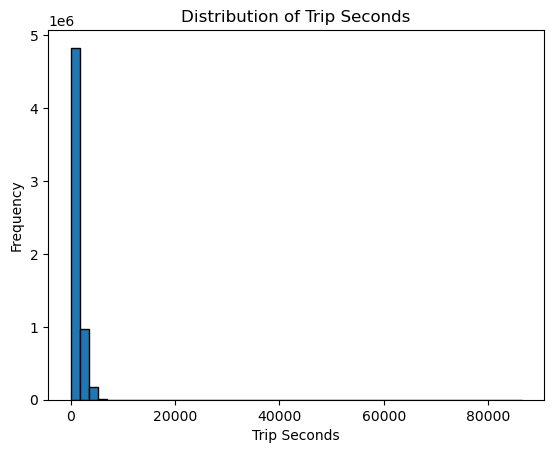

In [19]:
# Check Trip Seconds distribution

import matplotlib.pyplot as plt
plt.hist(data['Trip Seconds'], bins=50, edgecolor='black')
plt.title('Distribution of Trip Seconds')
plt.xlabel('Trip Seconds')
plt.ylabel('Frequency')
plt.show()

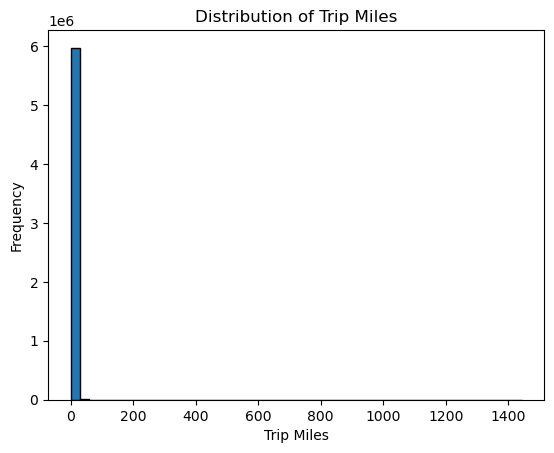

In [20]:
# Check Trip Miles distribution
plt.hist(data['Trip Miles'], bins=50, edgecolor='black')
plt.title('Distribution of Trip Miles')
plt.xlabel('Trip Miles')
plt.ylabel('Frequency')
plt.show()

In [21]:
# Display summary statistics for Trip Seconds and Trip Miles
print("Summary statistics for Trip Seconds:")
print(data['Trip Seconds'].describe())
print("\nSummary statistics for Trip Miles:")
print(data['Trip Miles'].describe())

Summary statistics for Trip Seconds:
count    5.984439e+06
mean     1.002965e+03
std      1.368227e+03
min      0.000000e+00
25%      3.600000e+02
50%      6.000000e+02
75%      1.326000e+03
max      8.638200e+04
Name: Trip Seconds, dtype: float64

Summary statistics for Trip Miles:
count    5.984439e+06
mean     4.625483e+00
std      7.193826e+00
min      0.000000e+00
25%      6.000000e-01
50%      1.300000e+00
75%      3.500000e+00
max      1.442800e+03
Name: Trip Miles, dtype: float64


In [22]:
# Load and clean data using Data class from data.py

from data import Data

# Initialize Data class - this loads and cleans the data
data_loader = Data('data/Data_2019-2023.csv')
cleaned_data = data_loader.raw_data
print(f"Data loaded and cleaned: {len(cleaned_data)} rows")


Data loaded: 5984439 rows
Data cleaned: 5954930 rows remaining
Data loaded and cleaned: 5954930 rows


In [ ]:
# Predict OD hourly demand, average duration, and average distance using Data class
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# --- 1) Create OD-hourly demand data using data.py ---
od_hourly = data_loader.create_data_demand(timestamp_duration='1h')

# --- 2) Feature engineering (time + zones) ---
od_hourly['Pickup Census Tract'] = od_hourly['Pickup Census Tract'].astype(str)
od_hourly['Dropoff Census Tract'] = od_hourly['Dropoff Census Tract'].astype(str)

# Category encoding for zones
pickup_categories = pd.Categorical(od_hourly['Pickup Census Tract']).categories
dropoff_categories = pd.Categorical(od_hourly['Dropoff Census Tract']).categories

od_hourly['pickup_code'] = pd.Categorical(
    od_hourly['Pickup Census Tract'], categories=pickup_categories
).codes
od_hourly['dropoff_code'] = pd.Categorical(
    od_hourly['Dropoff Census Tract'], categories=dropoff_categories
).codes

od_hourly['Trip Start Timestamp'] = pd.to_datetime(od_hourly['Trip Start Timestamp'])
od_hourly['hour'] = od_hourly['Trip Start Timestamp'].dt.hour
od_hourly['dayofweek'] = od_hourly['Trip Start Timestamp'].dt.dayofweek
od_hourly['month'] = od_hourly['Trip Start Timestamp'].dt.month
od_hourly['is_weekend'] = (od_hourly['dayofweek'] >= 5).astype(int)

feature_cols = ['pickup_code', 'dropoff_code', 'hour', 'dayofweek', 'month', 'is_weekend']
X = od_hourly[feature_cols]

# Targets
y_trips = od_hourly['Number of Trips']
y_time = od_hourly['Travelling Time Average']
y_dist = od_hourly['Trip Distance Average']

# --- 3) Train/test split (same rows for all targets) ---
X_train, X_test, y_trips_train, y_trips_test = train_test_split(
    X, y_trips, test_size=0.2, random_state=42
)

# Align other targets with the same sampled indices
y_time_train = y_time.loc[X_train.index]
y_time_test = y_time.loc[X_test.index]
y_dist_train = y_dist.loc[X_train.index]
y_dist_test = y_dist.loc[X_test.index]

# --- 4) Train one random-forest model per target ---
trips_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
time_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
dist_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

trips_model.fit(X_train, y_trips_train)
time_model.fit(X_train, y_time_train)
dist_model.fit(X_train, y_dist_train)

# --- 5) Evaluate ---
trips_pred_test = trips_model.predict(X_test)
time_pred_test = time_model.predict(X_test)
dist_pred_test = dist_model.predict(X_test)

print('--- Evaluation on test split ---')
print(f"Trips -> MSE: {mean_squared_error(y_trips_test, trips_pred_test):.4f}, R²: {r2_score(y_trips_test, trips_pred_test):.4f}")
print(f"Duration -> MSE: {mean_squared_error(y_time_test, time_pred_test):.4f}, R²: {r2_score(y_time_test, time_pred_test):.4f}")
print(f"Distance -> MSE: {mean_squared_error(y_dist_test, dist_pred_test):.4f}, R²: {r2_score(y_dist_test, dist_pred_test):.4f}")

# --- 6) Load OD observations to predict ---
observations_to_predict = pd.read_csv('data/observations_to_predict.csv', sep=';')
observations_to_predict['Trip Start Timestamp'] = pd.to_datetime(observations_to_predict['Trip Start Timestamp'])
observations_to_predict['Pickup Census Tract'] = observations_to_predict['Pickup Census Tract'].astype(str)
observations_to_predict['Dropoff Census Tract'] = observations_to_predict['Dropoff Census Tract'].astype(str)

# Encode with training categories (unknown zones -> code -1)
observations_to_predict['pickup_code'] = pd.Categorical(
    observations_to_predict['Pickup Census Tract'], categories=pickup_categories
).codes
observations_to_predict['dropoff_code'] = pd.Categorical(
    observations_to_predict['Dropoff Census Tract'], categories=dropoff_categories
).codes

observations_to_predict['hour'] = observations_to_predict['Trip Start Timestamp'].dt.hour
observations_to_predict['dayofweek'] = observations_to_predict['Trip Start Timestamp'].dt.dayofweek
observations_to_predict['month'] = observations_to_predict['Trip Start Timestamp'].dt.month
observations_to_predict['is_weekend'] = (observations_to_predict['dayofweek'] >= 5).astype(int)

X_new = observations_to_predict[feature_cols]

# --- 7) Predict the 3 requested outputs ---
pred_trips = np.clip(trips_model.predict(X_new), 0, None)
pred_time = np.clip(time_model.predict(X_new), 0, None)
pred_dist = np.clip(dist_model.predict(X_new), 0, None)

observations_to_predict['Predicted Number of Trips'] = np.rint(pred_trips).astype(int)
observations_to_predict['Predicted Avg Trip Duration (s)'] = pred_time
observations_to_predict['Predicted Avg Trip Distance (miles)'] = pred_dist

# Save predictions
output_path = 'data/predicted_observations.csv'
observations_to_predict.to_csv(output_path, index=False)
print(f"Predictions saved to {output_path}")

Data demand created: 2639123 OD-hour pairs
